# Trabajo Práctico: aprendizaje de máquina

Alumnos:

- Rodrigo Mesa
- Juan García
- Danilo Reitano


En este trabajo se desarrollará un algoritmo de predicción de series de tiempo, aplicado al dataset de Ecobicis de la Ciudad Autónoma de Buenos Aires correspondiente al año 2024. El objetivo principal del proyecto es predecir la cantidad de bicicletas utilizadas en el día siguiente, utilizando como base una ventana temporal de los siete días anteriores.

Para ello, se realizó un preprocesamiento del dataset original, estructurándolo de manera que pueda ser utilizado en este análisis. Al dato crudo (la cantidad diaria de bicicletas utilizadas) se le añadieron variables adicionales, tanto de calendario (día del mes, día de la semana, si es fin de semana, etc.) como climáticas (temperatura, precipitaciones, velocidad del viento).

En una primera instancia, se evaluará el desempeño de un modelo basado únicamente en la ventana temporal de siete días. Luego, se repetirá el análisis incorporando las variables adicionales, con el objetivo de mejorar la capacidad predictiva del modelo. Finalmente, se comparará el rendimiento entre modelos estadísticos y modelos de machine learning, analizando sus diferencias en cuanto a precisión y desempeño general.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

En primer lugar leemos el dataset estructurado para nuestro análsiis. En esta isntancia, lo que hicimos fue procesar el dataset original de ecobicis, el cual describía de forma detallada cada recorrido realizado; y lo estructuramos de modo tal que tengamos la cantidad de bicicletas que fueron utilizadas diariamente. A esto, se le sumó un dataset climático, el cual describe variables de temperatura, precipitaciones y viento. Por ultimo, se sumaron variables relacionadas al calendario.

In [20]:
# Cargar el dataset de entrenamiento
df_resumen = pd.read_parquet("final.parquet")
df_resumen.info()
#Asumimos que los dias con precipitaciones faltantes son días donde no llovió, por lo que rellenamos estos valores con 0
df_resumen.prcp.fillna(0, inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                366 non-null    object 
 1   cantidad_recorridos  366 non-null    int64  
 2   day_of_week          366 non-null    int32  
 3   is_weekend           366 non-null    bool   
 4   day_of_month         366 non-null    int32  
 5   month                366 non-null    int32  
 6   tavg                 366 non-null    float64
 7   prcp                 355 non-null    float64
 8   wspd                 366 non-null    float64
dtypes: bool(1), float64(3), int32(3), int64(1), object(1)
memory usage: 21.8+ KB


/tmp/ipykernel_34636/3018796685.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_resumen.prcp.fillna(0, inplace=True)


In [21]:
df_resumen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                366 non-null    object 
 1   cantidad_recorridos  366 non-null    int64  
 2   day_of_week          366 non-null    int32  
 3   is_weekend           366 non-null    bool   
 4   day_of_month         366 non-null    int32  
 5   month                366 non-null    int32  
 6   tavg                 366 non-null    float64
 7   prcp                 366 non-null    float64
 8   wspd                 366 non-null    float64
dtypes: bool(1), float64(3), int32(3), int64(1), object(1)
memory usage: 21.8+ KB


In [22]:
df_resumen.head(2000)

,fecha,cantidad_recorridos,day_of_week,is_weekend,day_of_month,month,tavg,prcp,wspd
0,2024-01-01,4787,1,False,1,1,25.2,2.2,9.5
1,2024-01-02,10017,2,False,2,1,24.9,0.0,9.7
2,2024-01-03,11045,3,False,3,1,24.2,9.9,11.6
3,2024-01-04,10936,4,False,4,1,25.2,0.0,11.8
4,2024-01-05,10253,5,False,5,1,21.2,3.0,11.4
...,...,...,...,...,...,...,...,...,...
361,2024-12-27,12548,5,False,27,12,22.9,0.0,7.3
362,2024-12-28,5625,6,True,28,12,22.7,0.0,8.5
363,2024-12-29,5943,7,True,29,12,23.0,0.0,9.9
364,2024-12-30,11286,1,False,30,12,24.2,0.0,10.7


## Análisis exploratorio:

Para analizar el comportamiento de la variable de salida, estudiaremos su distribución. Para mejorar el desempeño de los modelos, buscaremos que esta tienda a una distribución normal

<Axes: xlabel='cantidad_recorridos', ylabel='Count'>

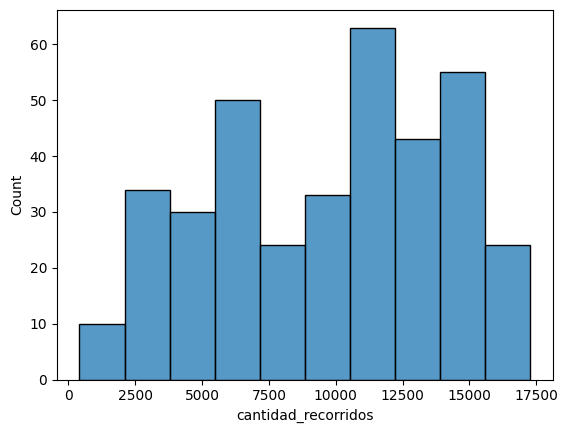

In [23]:
sns.histplot(df_resumen, x="cantidad_recorridos")

Encontramos que esta parece ser una superposición de dos distribuciones normales, para continuar este análisis en mayor detalle, realizamos una matriz de correlación, obtneiendo:

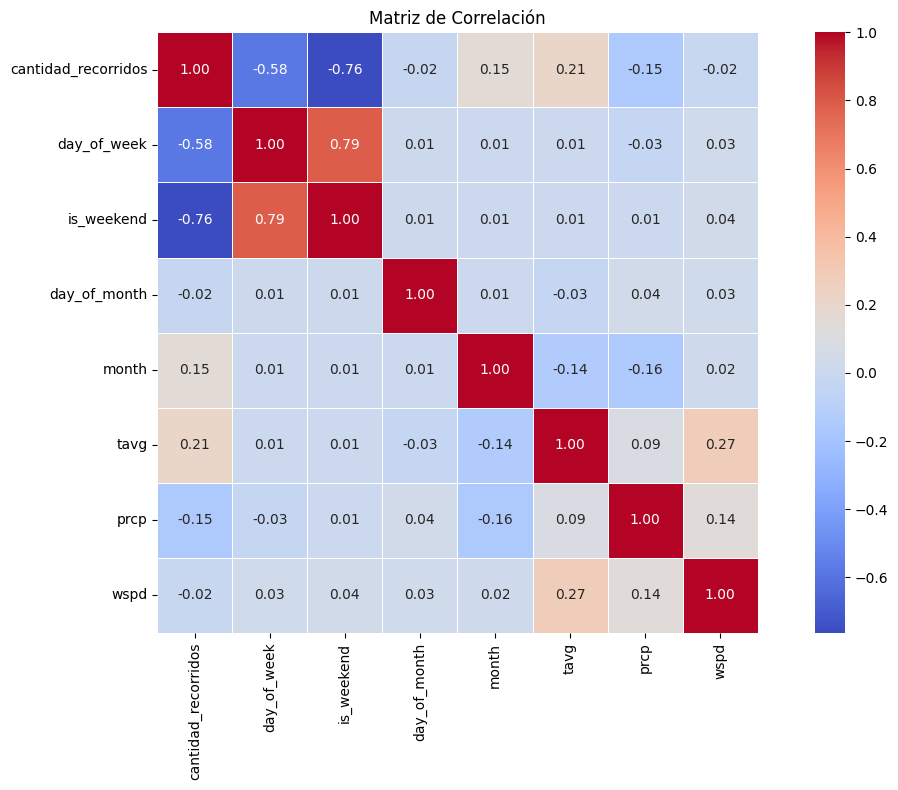

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular matriz de correlación
corr_matrix = df_resumen.drop(columns="fecha").corr()

# Crear un mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()


Observamos que las variables que mayor influencia tienen sobre la variable de salida: *cantidad de recorridos*, son las variables referidas al dia de la semana. Por ello, dividimos el histograma en base a si es o no dia de semana (variable con mayor correlación)

<Axes: xlabel='cantidad_recorridos', ylabel='Count'>

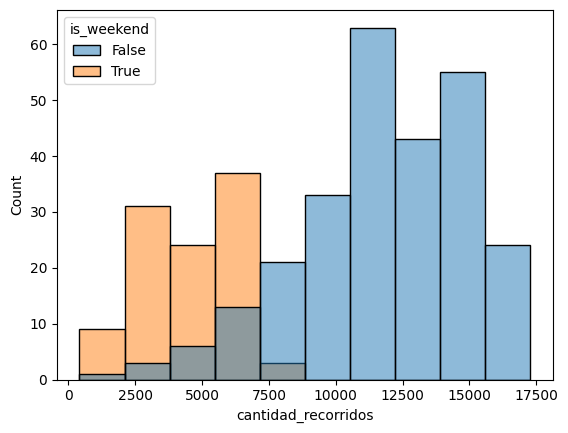

In [25]:
sns.histplot(df_resumen, x="cantidad_recorridos", hue='is_weekend')

Encontramos que si dividimos el histograma en base a si es fin de semana o no, podemos separar las dos distribuciones normales superpuestas. Continuando con el análisis, obtenemos:

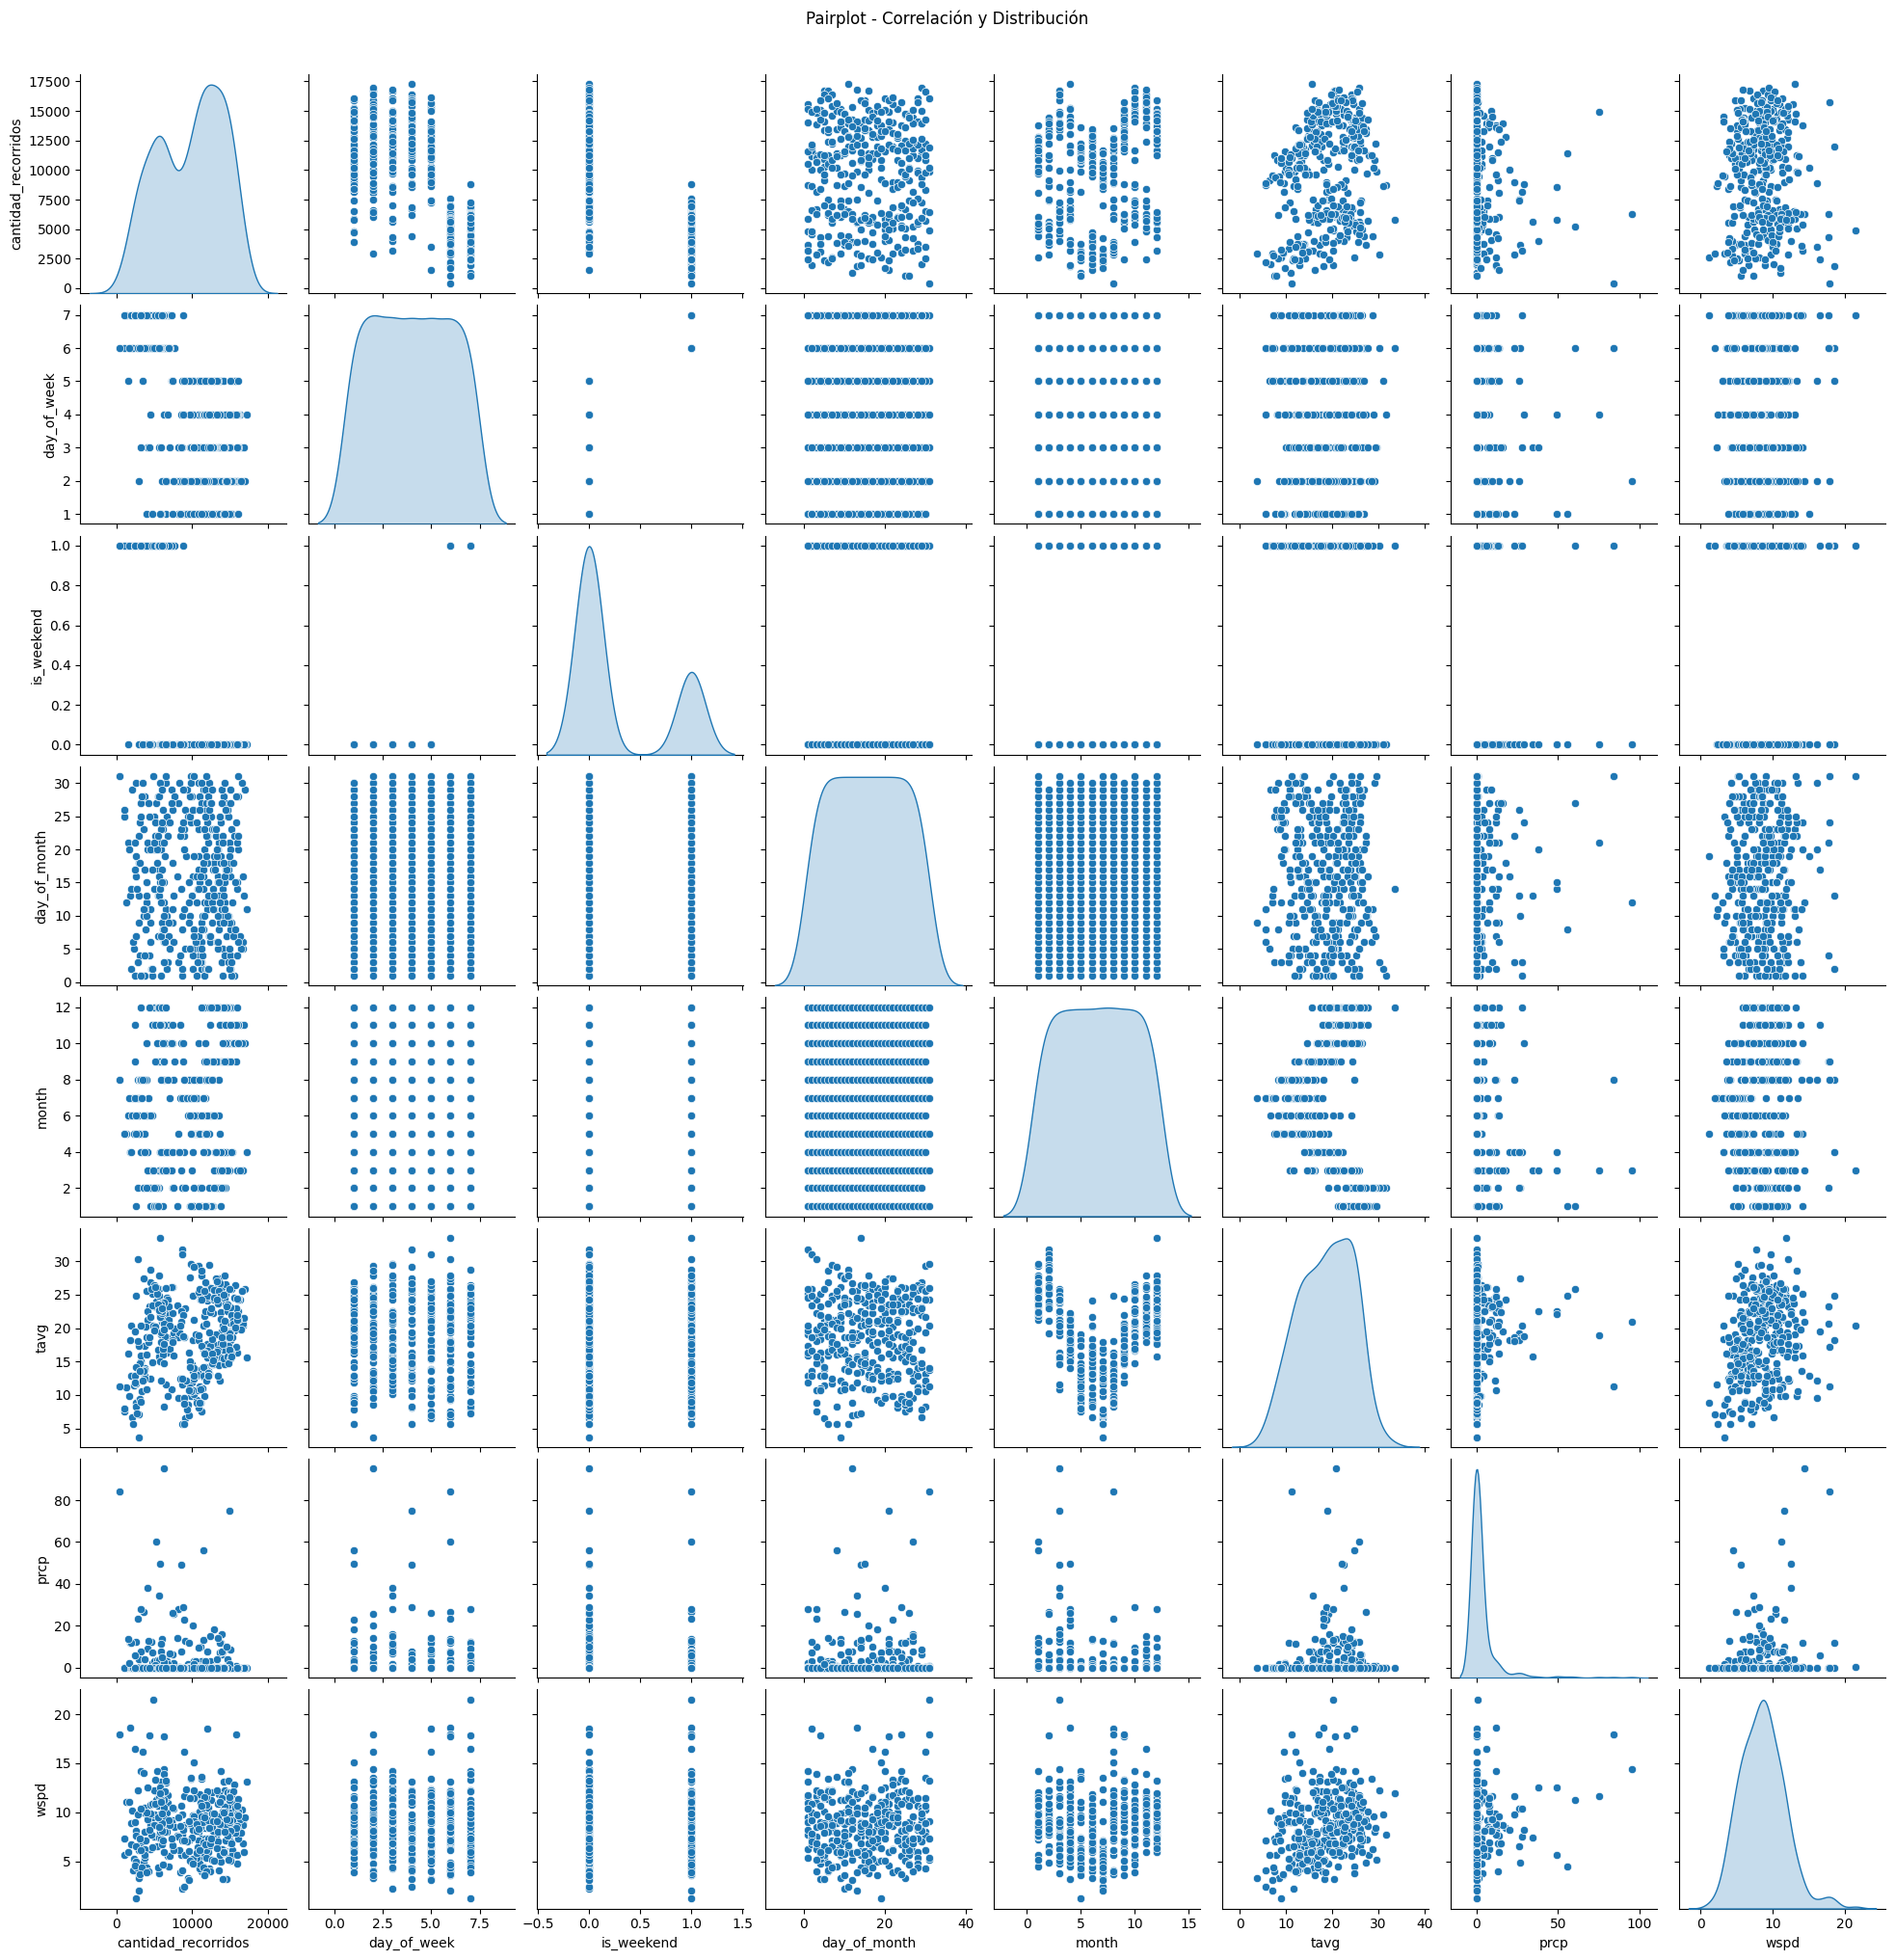

In [26]:
# Asumiendo que df es tu DataFrame
sns.pairplot(df_resumen, diag_kind='kde')  # Puedes usar 'hist' si prefieres histogramas
plt.suptitle("Pairplot - Correlación y Distribución", y=1.02)
plt.show()

Como vemos, las variables de temperatura y velocidad del viento presentan un comportamiento muy normal, por lo que al momento de adaptar estas variables, se utilizará la estandarización. En cuanto a las precipitaciones, debido al sesgo que presenta, se utilizará una normalización min max.

En los análisis de predicción de series de tiempo, el objetivo principal es identificar patrones repetitivos o tendencias a lo largo del tiempo. Por esta razón, las variables más relevantes (además de las previamente mencionadas) son las cantidades de bicicletas utilizadas en los n días anteriores al día que se desea predecir.

Con el fin de simplificar la complejidad del modelo, se realizará un análisis exploratorio de la serie temporal, con el propósito de detectar posibles tendencias, estacionalidades o ciclos presentes en los datos.

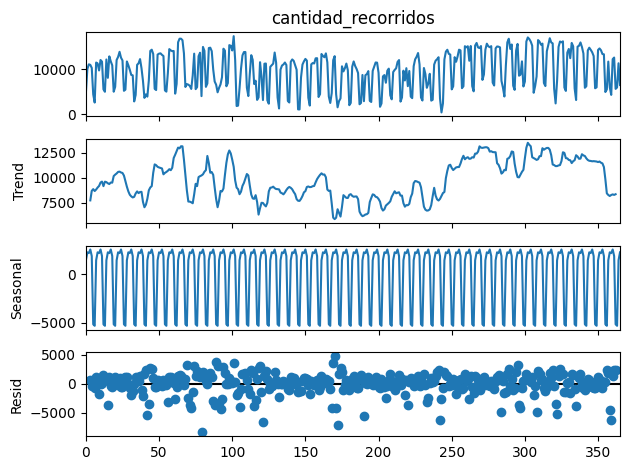

In [27]:
# Descomposición (usa 'additive' o 'multiplicative' según el comportamiento de la serie)
decomposition = seasonal_decompose(df_resumen['cantidad_recorridos'], model='additive', period=7)  # Por ejemplo: 7 si esperas estacionalidad semanal

# Plot
decomposition.plot()
plt.tight_layout()
plt.show()

Aquí podemos ver como en un principio todo señalaría que se tiene una cierta estacionalidad en la cantidad de recorridos. Como hipotesis consideraremos que esta estacionalidad es cada una semana. Para correborar ello, haremos dos análisis de correlación: ACF y PACF

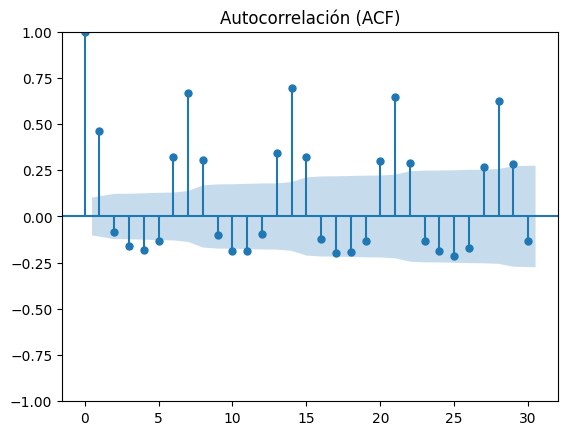

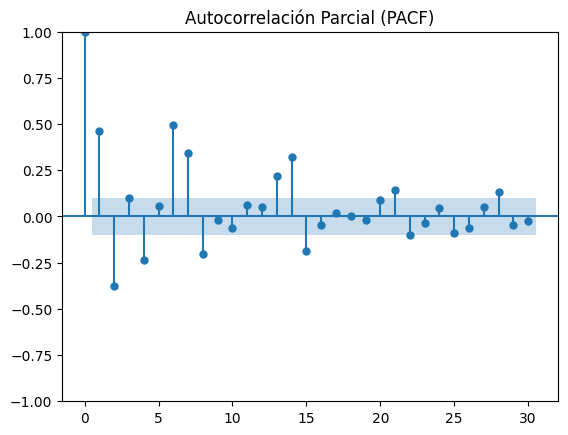

In [28]:
# ACF muestra correlaciones con lags anteriores
plot_acf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación (ACF)')
plt.show()

# PACF muestra correlaciones parciales (importante para AR terms)
plot_pacf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación Parcial (PACF)')
plt.show()

Aquí vemos como los picos principales se dan en multiplos de 7 días, lo que indica que tenemos una gran correlación segun el día de semana que estemos analizando (estacionalidad a nivel de semana). Validando con un test estadistico vemos que:

In [29]:
test_result = acorr_ljungbox(df_resumen['cantidad_recorridos'], lags=[7, 14, 21], return_df=True)
print(test_result)

       lb_stat      lb_pvalue
7   315.583544   2.834199e-64
14  615.224208  3.054744e-122
21  894.388725  8.329875e-176


Debido a que obtenemos valores menores a 0.01 (intervalo de confianza) podemos asegurar que la estacionalidad cada 7 días existe. Con ello, nuestras variables de entranamiento serán en un principio las cantidades de bicicletas utilizadas, los 7 días anteriores. Tendremos entonces 7 columnas, una para cada dia anterior. Nuestra variable de salida entonces será la cantidad de bicicletas utilizadas para el día siguiente.

## Entrenamiento de modelo

En esta sección se comenzará a entrenar los modelos, se evaluarán tres casos principales:

- Modelo estadístico: se realizará unicamente utilizando el lag de los ultimos 7 días en el pasado, sin las variables adicionales. Para esta caso, utilizaremos un modelo SARIMAX.

- Modelo de machine learning: para este caso haremos una regresion mediante XGBOOST. Para utilizar este modelo, necesitamos reestructurar el dataset, adicionando columnas con los lags de fecha. A su vez, compararemos el desempeño con y sin features adicionales.

En primer lugar, realizamos la primera prueba utilizando un modelo SARIMAX. En él, estructuramos la información según el requerimiento del modelo y generamos un dataset de entrenamiento y otro de validación. En este caso, utilizamos los ultimos 30 días del año como datos de test. A lo largo de todos los entrenamientos, se mediará el desempeño con el MAE

/home/rodri/Documents/Maestria/proyectos_maestria/AprendizajeDeMaquinas/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/rodri/Documents/Maestria/proyectos_maestria/AprendizajeDeMaquinas/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 1977.52, RMSE: 3349.38


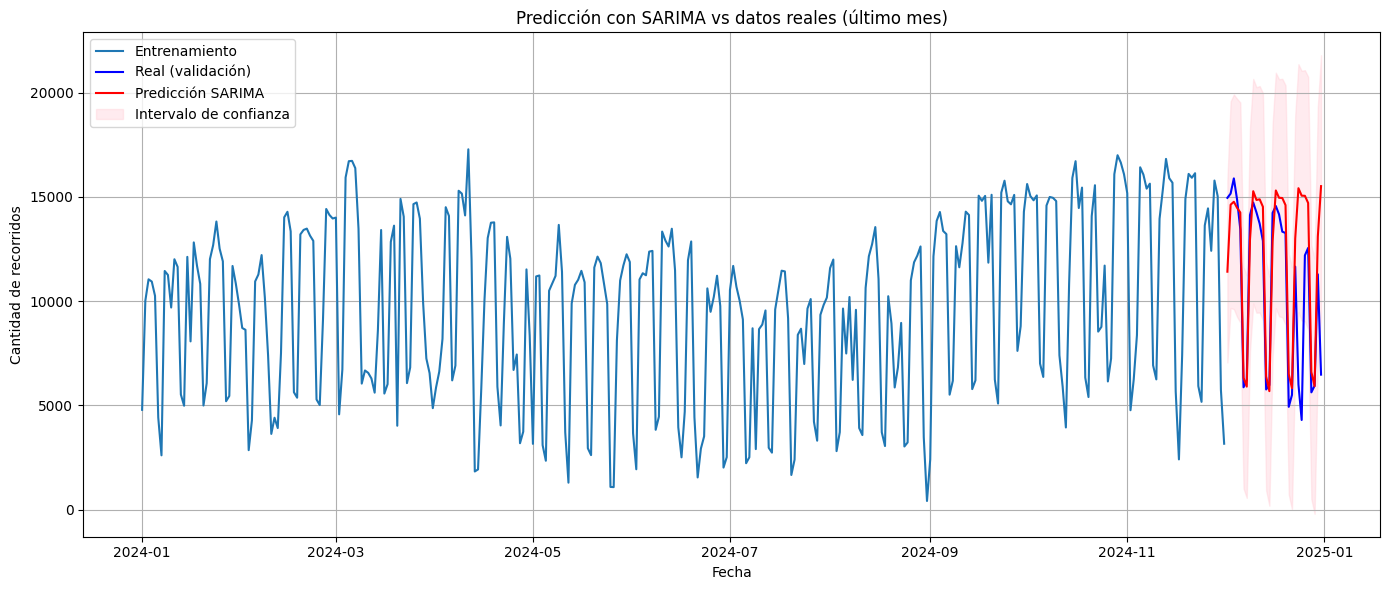

In [30]:
# Asegurar que el índice es datetime
df_resumen = df_resumen.set_index("fecha")
df_resumen.index = pd.to_datetime(df_resumen.index)

# Separar el último mes (30 días) para validación
n_valid = 30
train = df_resumen.iloc[:-n_valid]
valid = df_resumen.iloc[-n_valid:]

# Entrenar modelo SARIMA con estacionalidad semanal
model = SARIMAX(train['cantidad_recorridos'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

# Predecir sobre el período de validación
forecast = result.get_forecast(steps=n_valid)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluar el modelo
mae = mean_absolute_error(valid['cantidad_recorridos'], forecast_mean)
rmse = np.sqrt(mean_squared_error(valid['cantidad_recorridos'], forecast_mean))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cantidad_recorridos'], label='Entrenamiento')
plt.plot(valid.index, valid['cantidad_recorridos'], label='Real (validación)', color='blue')
plt.plot(valid.index, forecast_mean, label='Predicción SARIMA', color='red')
plt.fill_between(valid.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de confianza')
plt.legend()
plt.title('Predicción con SARIMA vs datos reales (último mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de recorridos')
plt.grid(True)
plt.tight_layout()
plt.show()


Resultados SARIMAX:
- MAE: 1977.52
- RMSE: 3349.38

Ahora, realizaremos el mismo análisis para el modelo XGBOOST

MAE: 1509.21, RMSE: 2302.09


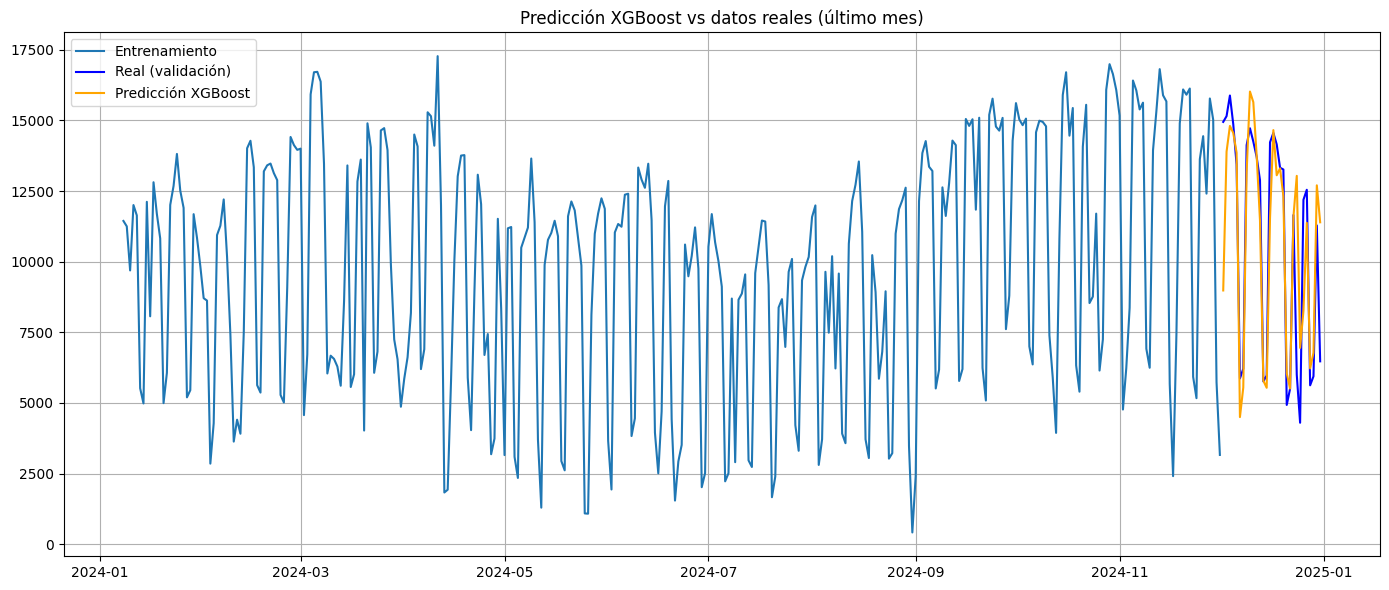

In [31]:
# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

Resultados XGBOOST:

- MAE: 1509.21 
- RMSE: 2302.09

Utilizando otros hiperparámetros, obtenemos:

MAE: 1346.44, RMSE: 2084.57


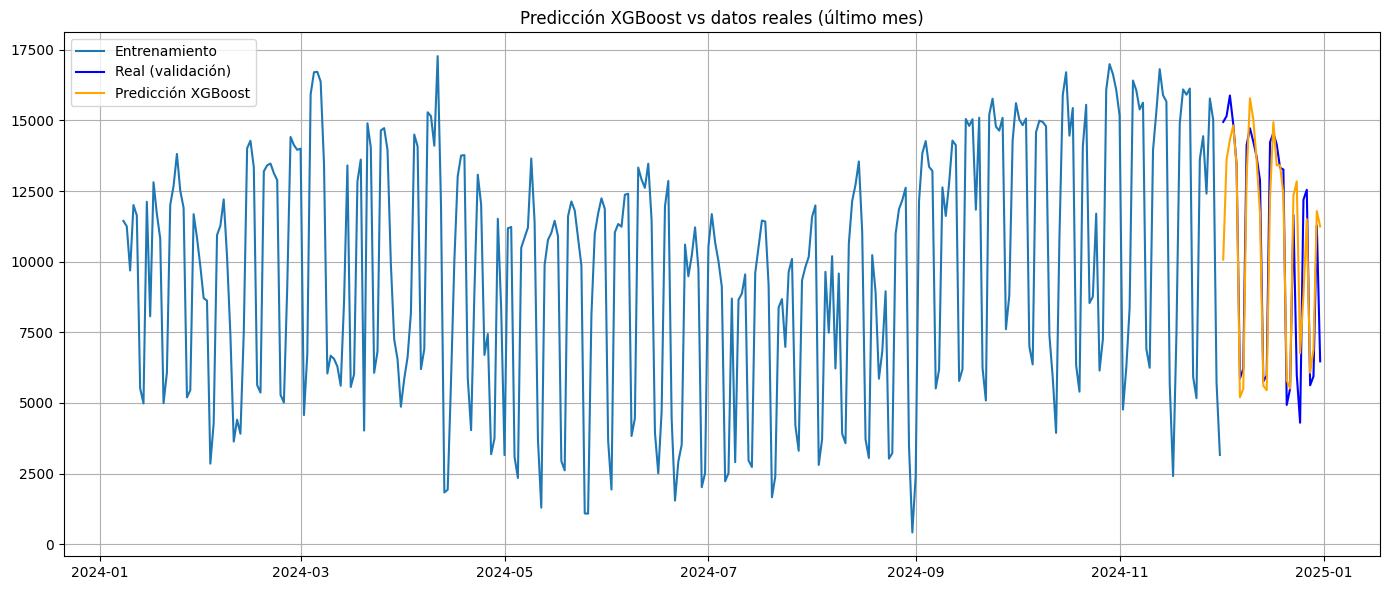

In [32]:
# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=400, learning_rate=0.01, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

Resultados modificando parámetros:
- MAE: 1346.44
- RMSE: 2084.57

Ahora en esta siguiente etápa comenzaremos a utilizar los nuevos atributos incorporados, buscando mejorar el desempeño del modelo. Como observamos anteriormente, ninguna de estas variables tenía una correlación muy elevada, salvo el indicador de fin de semana o día de semana. De manera similar al anterior, estructuraremos el dataset, aplicando en este caso normalizaciones para las variables adicionadas.

In [53]:
import pandas as pd

def crear_ventanas_lags(df, feature_cols, target_col="cantidad_recorridos", window_size=7):
    df = df.copy()  # Evitamos modificar el DataFrame original
    columnas = []

    # Agregar las columnas de los features con lags t0 a t(window_size-1)
    for lag in range(window_size + 1):
        for feature in feature_cols:
            if not(feature == "cantidad_recorridos" and lag == window_size):
                col_name = f"{feature}_t{lag}"
                df[col_name] = df[feature].shift(-lag)
                columnas.append(col_name)
    
    # Agregar la columna objetivo (target) para t+window_size
    #target_name = f"{target_col}_t{window_size}"
    #df[target_name] = df[target_col].shift(-window_size)
    #columnas.append(target_name)

    # Eliminar las filas con valores NaN que se crean por el uso de shift
    df_lags = df[columnas].dropna().reset_index(drop=True)

    return df_lags

features = ["month", "day_of_month", "day_of_week", "is_weekend", "tavg", "prcp", "wspd", "cantidad_recorridos"]

Ahora, aplicamos un pipeline de transformación de columnas sobre nuestras variables:

- mes: onehot encoder
- dia de mes y dia de semana: transormaciones senoidales y cosenoidales para describir comportamiento ciclico
- Temperatura y velocidad de viento: estandarización
- precipitaciones: min max

In [54]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7

def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year["month", "day_of_month", "day_of_week", "is_weekend", "tavg", "prcp", "wspd", "cantidad_recorridos"]
        ('month_onehot', OneHotEncoder(sparse_output=False), ['month']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(DAY_OF_MONTH_PERIOD, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(DAY_OF_MONTH_PERIOD, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(DAY_OF_WEEK_PERIOD, "day_of_week"), ['day_of_week']),
        ('day_of_week_cos', cos_transformer(DAY_OF_WEEK_PERIOD, "day_of_week"), ['day_of_week']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp']),

        # Don't edit 'cantidad_recorridos'
        ('passthrough_col', 'passthrough', ['is_weekend', 'cantidad_recorridos'])
    ],
    remainder='drop'  # Esto evita agregar columnas no especificadas
)

In [55]:
# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_resumen[features].iloc[:-n_valid]
valid = df_resumen[features].iloc[-n_valid:]

X_train = train
y_train = train['cantidad_recorridos'].shift(-7).dropna()
X_valid = valid
y_valid = valid['cantidad_recorridos'].shift(-7).dropna()

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])
pipeline

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('month_onehot', ...), ('day_of_month_sin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
pipeline.fit(X_train)

feature_names = []
for name, trans, cols in preprocessor.transformers_:
    if hasattr(trans, 'get_feature_names_out'):
        try:
            names = trans.get_feature_names_out(cols)
        except:
            names = [f"{col}_{name}" for col in cols]
    elif trans == 'passthrough':
        names = cols
    else:
        names = [f"{col}_{name}" for col in cols]
    feature_names.extend(names)

X_train_transform = pipeline.transform(X_train)
X_train_transformed_df = pd.DataFrame(X_train_transform, columns=feature_names, index=X_train.index)

X_test_transform = pipeline.transform(X_valid)
X_test_transformed_df = pd.DataFrame(X_test_transform, columns=feature_names, index=X_valid.index)

X_test_transformed_df.dtypes

month_1                          object
month_2                          object
month_3                          object
month_4                          object
month_5                          object
month_6                          object
month_7                          object
month_8                          object
month_9                          object
month_10                         object
month_11                         object
month_12                         object
day_of_month_day_of_month_sin    object
day_of_month_day_of_month_cos    object
day_of_week_day_of_week_sin      object
day_of_week_day_of_week_cos      object
tavg                             object
wspd                             object
prcp                             object
is_weekend                       object
cantidad_recorridos              object
dtype: object

In [57]:
X_model_train = crear_ventanas_lags(X_train_transformed_df, feature_names)
X_model_test = crear_ventanas_lags(X_test_transformed_df, feature_names)

def cast_columns_by_name(df):
    for col in df.columns:
        if col.startswith("month_") or col.startswith("is_weekend_"):
            df[col] = df[col].astype(bool)

        elif (
            "day_of_month_sin" in col or
            "day_of_month_cos" in col or
            "day_of_week_sin" in col or
            "day_of_week_cos" in col or
            col.startswith("tavg_") or
            col.startswith("wspd_") or
            col.startswith("prcp_")
        ):
            df[col] = df[col].astype(float)

        elif col.startswith("cantidad_recorridos_"):
            df[col] = df[col].astype(int)

    return df

X_model_train = cast_columns_by_name(X_model_train)
X_model_test = cast_columns_by_name(X_model_test)

/tmp/ipykernel_30804/2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[feature].shift(-lag)
/tmp/ipykernel_30804/2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[feature].shift(-lag)
/tmp/ipykernel_30804/2105347847.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 

Con esto, entrenamos nuestro dataset, obteniendo:

MAE: 1451.78, RMSE: 2418.71


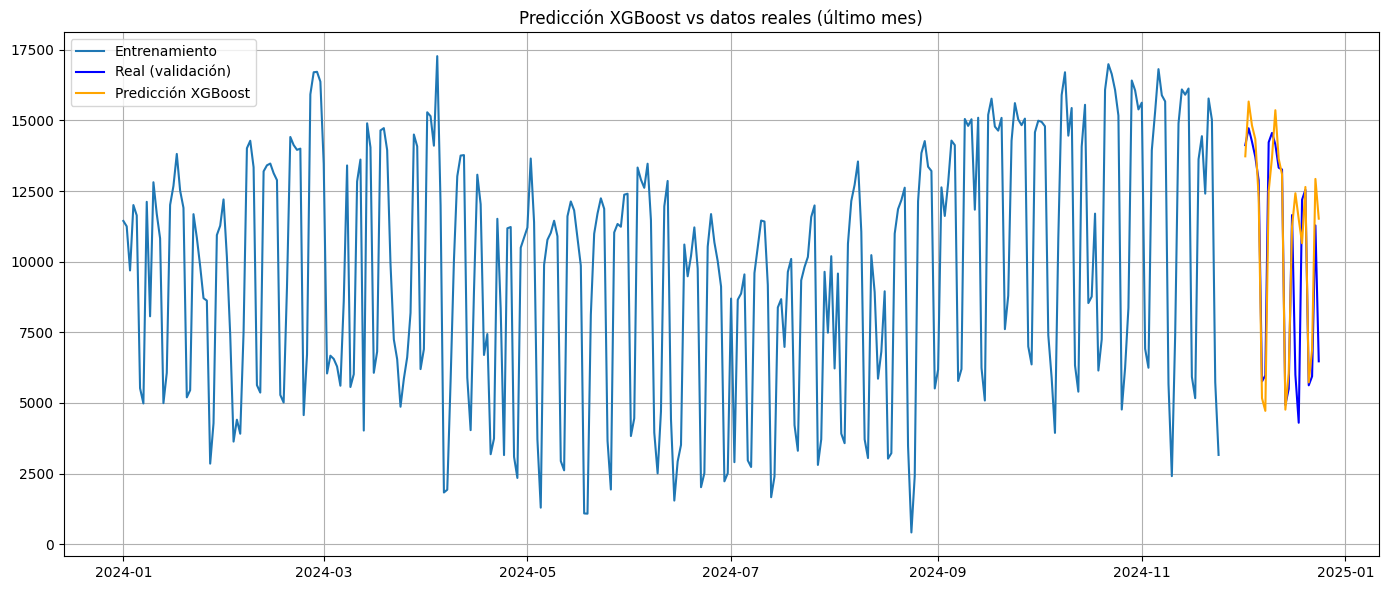

In [59]:
# Entrenar XGBoost
model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_model_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_model_test)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

Resultados de modelo entrenando con variables adicionales:
- MAE: 1451.78
- RMSE: 2418.71
￼
Como vemos, el modelo mejora ligeramente. Para mejorar entonces la predicción, procedemos a optimizar los hiperparámetros del modelo. Para ello, hacemos uso de optuna:

[I 2025-06-17 20:01:15,464] A new study created in memory with name: no-name-0665351e-610a-4109-b7e1-17de12ea620a
[I 2025-06-17 20:01:22,495] Trial 0 finished with value: 1418.6146399456522 and parameters: {'n_estimators': 692, 'max_depth': 6, 'learning_rate': 0.017172834863540765, 'subsample': 0.6980153101071289, 'colsample_bytree': 0.6760596229941456, 'gamma': 4.31758439725175}. Best is trial 0 with value: 1418.6146399456522.
[I 2025-06-17 20:01:26,313] Trial 1 finished with value: 2011.104640794837 and parameters: {'n_estimators': 639, 'max_depth': 7, 'learning_rate': 0.22065557415992212, 'subsample': 0.5272966508440255, 'colsample_bytree': 0.8317855192567809, 'gamma': 0.8490023658151041}. Best is trial 0 with value: 1418.6146399456522.
[I 2025-06-17 20:01:29,057] Trial 2 finished with value: 1537.6087168817935 and parameters: {'n_estimators': 267, 'max_depth': 6, 'learning_rate': 0.17325766531016434, 'subsample': 0.6021051069267109, 'colsample_bytree': 0.7857987687931074, 'gamma': 

Mejores parámetros encontrados: {'n_estimators': 377, 'max_depth': 5, 'learning_rate': 0.010422465388690766, 'subsample': 0.7265123140072641, 'colsample_bytree': 0.8111129278441792, 'gamma': 1.1402543730925117}
MAE: 1342.99, RMSE: 2410.56


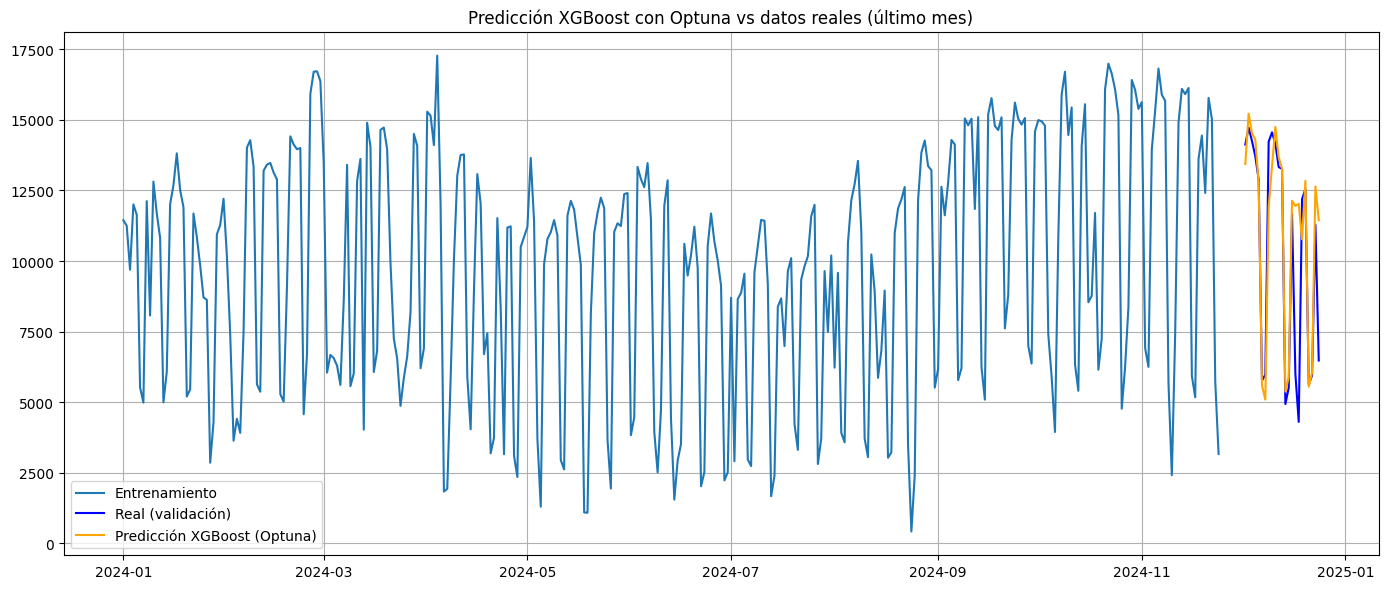

In [64]:
import optuna

# Define the Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**params)
    model.fit(X_model_train, y_train, eval_set=[(X_model_test, y_valid)], verbose=False)

    y_pred = model.predict(X_model_test)
    mae = mean_absolute_error(y_valid, y_pred)
    return mae  # You can also use MAE or a custom metric

# Run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=600)  # 50 trials or 10 minutes

# Best model parameters
best_params = study.best_params
print("Mejores parámetros encontrados:", best_params)

# Train final model with best parameters
final_model = XGBRegressor(**best_params)
final_model.fit(X_model_train, y_train)

# Predict and evaluate
y_pred = final_model.predict(X_model_test)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Plot predictions
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost (Optuna)', color='orange')
plt.legend()
plt.title('Predicción XGBoost con Optuna vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

Resultados modelo optimizado:
- MAE: 1342.99
- RMSE: 2410.56

Podemos ver como mejoramos el resultado anterior mediante la búsqueda de hiperparámetros. 

## Conclusión

A lo largo del proyecto, pudimos validar distintas metodologías para predicción de series de tiempo para un caso real. Pudimos observar como la utilización de modelos mas robustos puede mejorar el desempeño de la predicción. Analizamos también la estructuracion característica de un modelo de predicción de serie de tiempo, y la transformación de sus variables de entrada.

También, se pudo ver como no siempre la adición de nuevas variables al modelo necesariamente mejoran su desempeño: se agregaron nuevas variables, volviendo al entrenamiento mas complejo, sin obtener resultados comparativamente mejores. También, podemos destacar la utilización de herramientas analiticas para poder comprender mejor los datos: correlaciones, distribuciones, entre otras.